In [8]:
import numpy as np

data = np.load('workspace/pca.npy')

In [10]:
import warnings
warnings.filterwarnings('ignore')

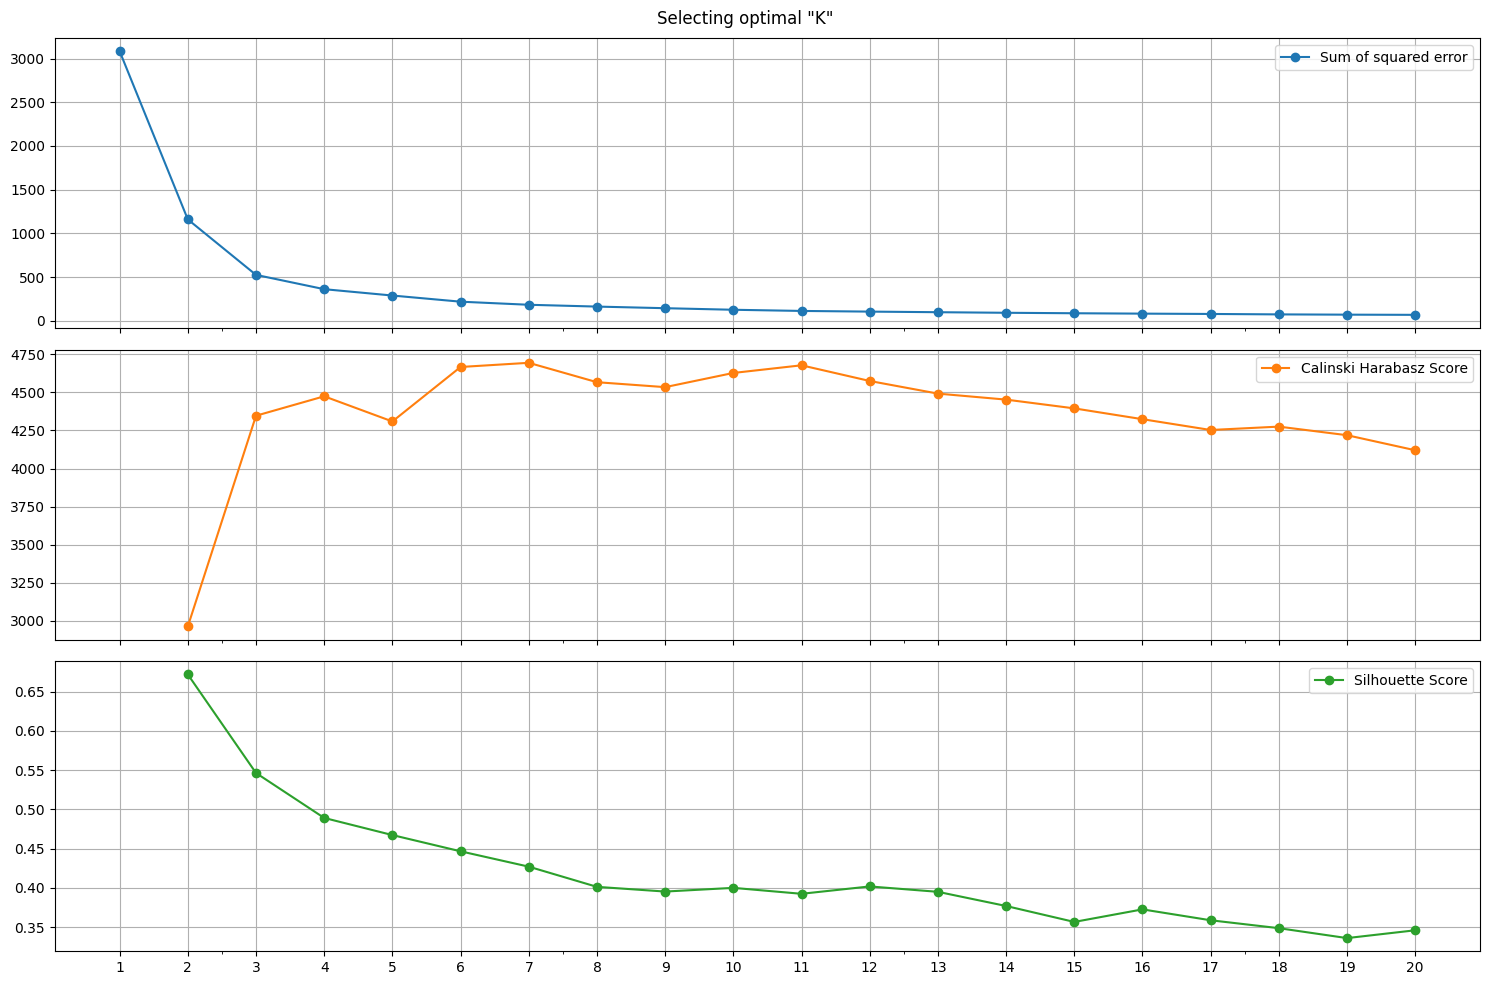

In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score, silhouette_score

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

search_range = range(1, 21)
report = {}
for k in search_range:
    temp_dict = {}
    kmeans = KMeans(init='k-means++',
                    algorithm='auto',
                    n_clusters=k,
                    max_iter=1000,
                    random_state=1,
                    verbose=0).fit(data)
    inertia = kmeans.inertia_
    temp_dict['Sum of squared error'] = inertia
    try:
        cluster = kmeans.predict(data)
        chs = calinski_harabasz_score(data, cluster)
        ss = silhouette_score(data, cluster)
        temp_dict['Calinski Harabasz Score'] = chs
        temp_dict['Silhouette Score'] = ss
        report[k] = temp_dict
    except:
        report[k] = temp_dict

report_df = pd.DataFrame(report).T
report_df.plot(figsize=(15, 10),
               xticks=search_range,
               grid=True,
               title=f'Selecting optimal "K"',
               subplots=True,
               marker='o',
               sharex=True)
plt.tight_layout()

In [19]:
from sklearn.cluster import KMeans

model = KMeans(n_clusters=8, random_state=0, algorithm='auto')
model.fit(data)

KMeans(algorithm='auto', random_state=0)

In [20]:
pred = model.predict(data)
pred

array([0, 2, 3, ..., 3, 1, 1], dtype=int32)

In [21]:
from sklearn.metrics import silhouette_samples, silhouette_score

k_average_score = silhouette_score(data, pred)
print('Average Silhouette Score:{0:.3f}'.format(k_average_score))

Average Silhouette Score:0.403


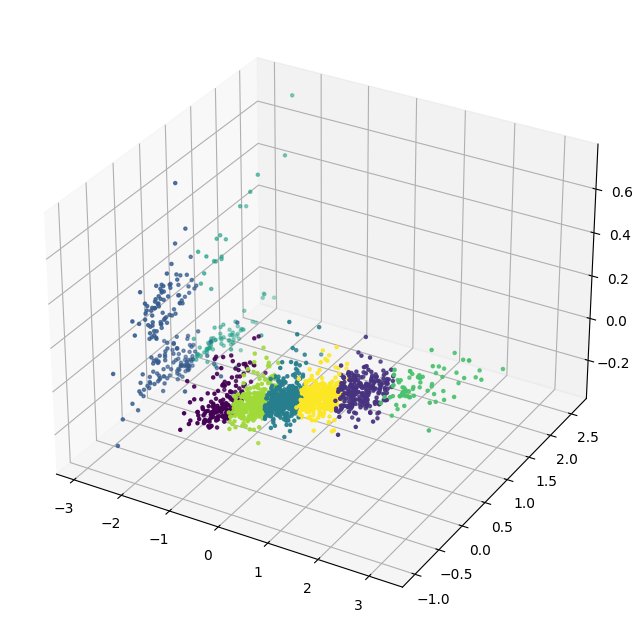

In [22]:
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(data[:,0], data[:,1], data[:,2], s=5, c = pred)
plt.show()

In [29]:
import json

with open('workspace/f.json', 'r') as file:
    word = json.load(file)

In [30]:
import pandas as pd

df = pd.DataFrame({'word':word, 'c':pred})
df

,word,c
0,"[한적한, 골목, 차량, 진입, 가능, 있다, 오랜, 만, 왔더니, 다르다, 자주,...",0
1,"[윰니, 역삼동, 퓨전, 토마, 돈, 산, 토마, 놀러, 갔다가, 덮, 밥, 땡겨서...",2
2,"[열정, 혼잡, 도의, 식도락, 여행, 들어가자마자, 부셨어요, 황홀한, 블링블링,...",3
3,"[자유로운, 맛, 작은, 골목길, 걸어가다, 보면, 곳, 나타납니다, 입구, 지나면...",6
4,"[독특한, 경험, 점심시간, 바쁜, 떠나, 머릿속, 떠올랐던, 찾았어요, 도착, 한...",0
...,...,...
1782,"[예약, 등촌, 샤브샤브, 즐겨가는데, 김광석, 첫, 김광석, 찾기, 쉬운, 곳, ...",2
1783,"[곰돌이, 부엉이, 산장, 다녀왔어요, 다녀온, 부엉이, 산장, 고급스러운, 대리석...",3
1784,"[웨이브, 퀄리티, 다양성, 돋보이는, 세계, 주, 웨이브, 입장, 띄는, 건, 에...",3
1785,"[불, 백, 소개, 해드릴, 불, 백, 기본, 반찬, 쌈장, 쌈무, 마카로니, 샐러...",1


In [31]:
df['word'].to_csv('workspace/word.csv')

In [28]:
df.to_csv('workspace/clustering.csv')

In [27]:
df[df['c'] == 0]

,word,c
0,"[한적한, 골목, 위치, 해, 있지만, 차량, 진입, 가능, 층, 위치, 해, 있다...",0
4,"[독특한, 경험, 문득, 연남, 점, 연남, 맛집, 어느, 날, 평일, 점심시간, ...",0
7,"[날씨, 많이, 더워졌죠, 서늘한, 밤, 공기, 즐기기, 좋은, 피맥, 뉴, 오더,...",0
14,"[흠, 흠, 오늘, 부터, 연남, 타코, 맛집, 시작, 왜냐면, 엊그제, 연남, 이...",0
31,"[안녕하세요, 지난, 신나는, 불금, 이쁜, 동생, 홍대, 놀러, 가자, 그래서, ...",0
...,...,...
1686,"[오랜, 만, 맛집, 포스팅, 왜냐하면, 도시락, 편의점, 의존, 했기, 때문, 죠...",0
1687,"[안녕하세요, 단지, 로그, 입니다, 친구, 비, 오는, 날, 사고, 나서, 근처,...",0
1702,"[어제, 갈비찜, 먹으러, 다녀왔어요, 평일, 저녁, 시간, 비도, 왔는데도, 웨이...",0
1716,"[요즘, SNS, 올라오는, 맛집, 보면서, 마음, 한쪽, 꼭, 콕, 찔리듯, 나도...",0
